In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request

import pandas as pd

In [2]:
import tensorflow as tf

2026-06-28 16:26:00.672688: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-28 16:26:00.774723: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-28 16:26:03.075588: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
import torch 
import torchvision

In [4]:
data = pd.read_csv("../solutions/galaxyquasar.csv")
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [5]:
cls = []
for c in data['class']:
    if c=='QSO': cls = np.append(cls, 1)
    elif c=='GALAXY': cls = np.append(cls, 0)

In [6]:
u_g = np.array(data['u']-data['g'])
g_r = np.array(data['g']-data['r'])
r_i = np.array(data['r']-data['i'])
i_z = np.array(data['i']-data['z'])
z = np.array(data['z1'])
zerr = np.array(data['zerr'])

In [7]:
X = np.array([u_g, g_r, r_i, i_z, z]).T
y = cls

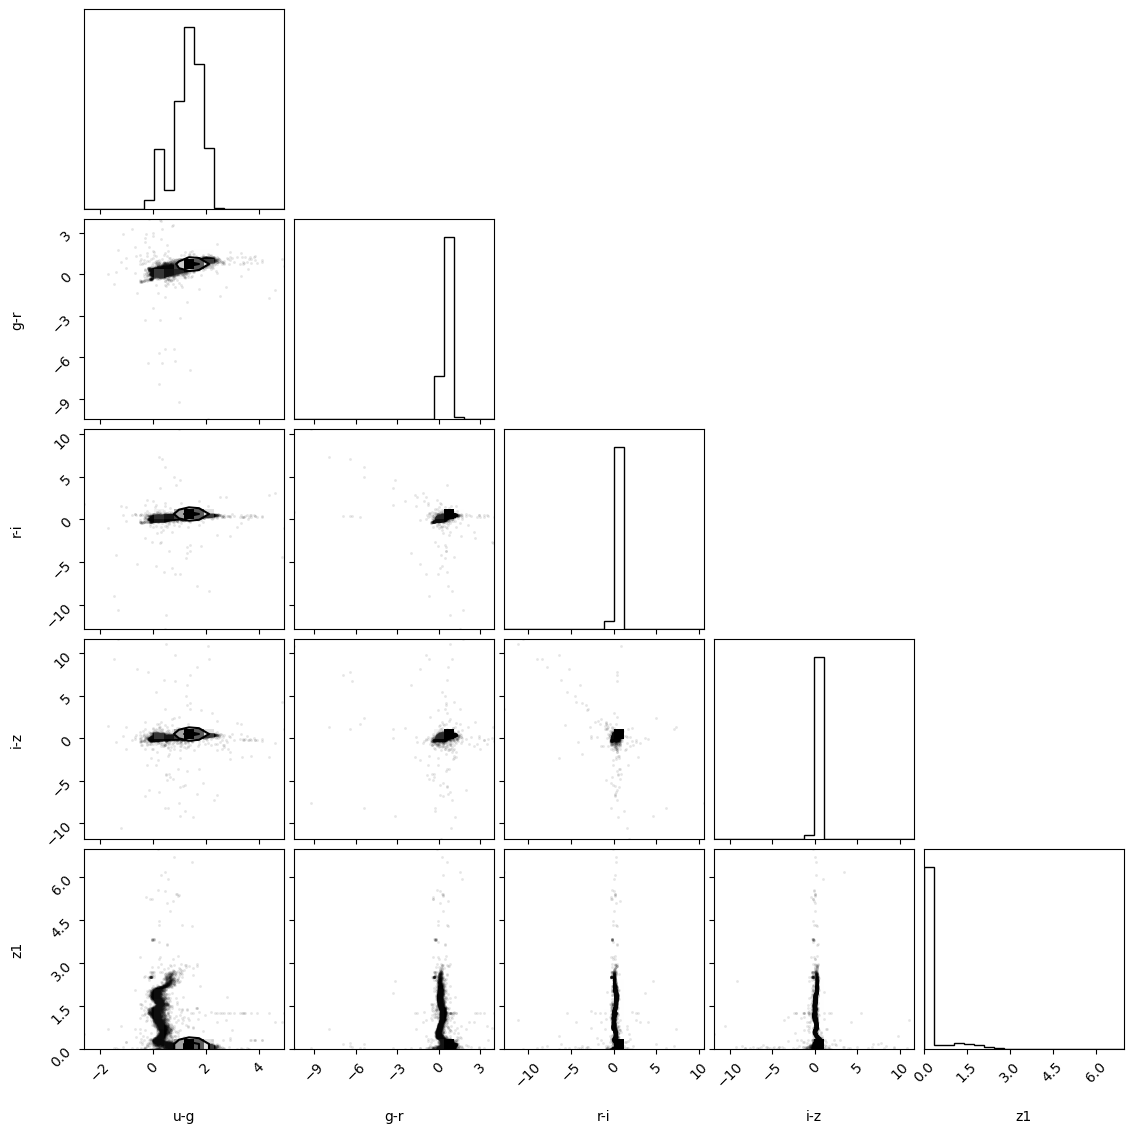

In [8]:
import corner
corner.corner(np.array([u_g,g_r,r_i,i_z,z]).T, labels=['u-g', 'g-r', 'r-i', 'i-z','z1']);

In [9]:
bins = np.linspace(-2,3,100)
bins2 = np.linspace(-4,4,100)

In [10]:
from astroML.utils import split_samples
from astroML.utils import completeness_contamination
from sklearn.metrics import confusion_matrix

# Without a Neural Network

In [11]:
(X_train_kn, X_test_kn), (y_train_kn, y_test_kn) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)

X_valid_kn, X_train = X_train_kn[:12000], X_train_kn[12000:]
y_valid_kn, y_train = y_train_kn[:12000], y_train_kn[12000:]


In [12]:
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier(5) 
kn.fit(X_train_kn,y_train_kn)

y_pred_kn = kn.predict(X_test_kn)

In [13]:
completeness, contamination = completeness_contamination(y_pred_kn, y_test_kn)

print("completeness", completeness)
print("contamination", contamination)

C = confusion_matrix(y_test_kn, y_pred_kn)
tn, fp, fn, tp = C.ravel()

print(C)

print("\nfraction of correct classifications", (tp+tn)/(tp+fp+tn+fn))

completeness 0.9603174603174603
contamination 0.013395457192778102
[[10713    23]
 [   70  1694]]

fraction of correct classifications 0.99256


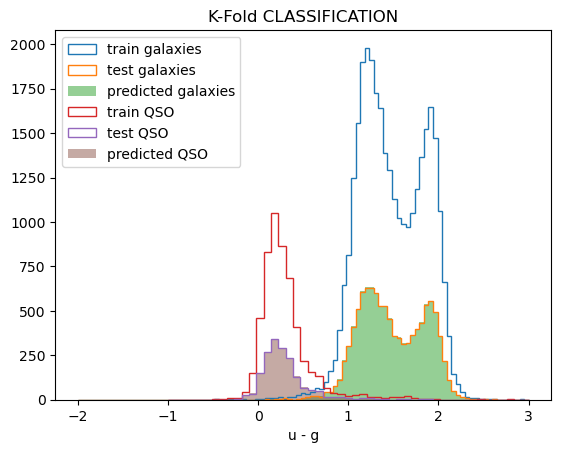

In [14]:
bins3 = np.linspace(-1,3,50)

plt.hist(X_train_kn[:,0][y_train_kn==0], bins, histtype='step', label='train galaxies')
plt.hist(X_test_kn[:,0][y_test_kn==0], bins, histtype='step', label='test galaxies')
plt.hist(X_test_kn[:,0][y_pred_kn==0], bins, label='predicted galaxies', alpha = 0.5)

plt.hist(X_train_kn[:,0][y_train_kn==1], bins3, histtype='step', label='train QSO')
plt.hist(X_test_kn[:,0][y_test_kn==1], bins3, histtype='step', label='test QSO')
plt.hist(X_test_kn[:,0][y_pred_kn==1], bins3, label='predicted QSO', alpha = 0.5)


plt.title('K-Fold CLASSIFICATION')
plt.xlabel('u - g')
plt.legend();

# Simpler CNN model

In [15]:
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler


sc = StandardScaler()
Xs = sc.fit_transform(X)

(X_train_full, X_test_full), (y_train_full, y_test_full) = split_samples(Xs, y, [0.75, 0.25],
                                                     random_state=0)

X_train_full.shape, y_train_full.shape

((37500, 5), (37500,))

In [16]:
from tensorflow import keras


keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tf.random.set_seed(42)



X_valid, X_train = X_train_full[:12000], X_train_full[12000:]
y_valid, y_train = y_train_full[:12000], y_train_full[12000:]
X_test = X_test_full 
y_test = y_test_full

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)


(25500, 5) (25500,)
(12000, 5) (12000,)
(12500, 5) (12500,)


In [17]:
X_train = X_train[:,:,np.newaxis]
X_valid = X_valid[:,:,np.newaxis]
X_test = X_test[:,:,np.newaxis]

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(25500, 5, 1) (25500,)
(12000, 5, 1) (12000,)
(12500, 5, 1) (12500,)


In [18]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=(5,1)),
    keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'), # Rectified Linear Unit
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(units=2, activation='softmax'),
])

/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2026-06-28 16:26:11.774845: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [19]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 450 (1.76 KB)

 Trainable params: 450 (1.76 KB)

 Non-trainable params: 0 (0.00 B)

None


In [20]:
# last_epoch = 30

# model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=), metrics=["accuracy"])
# clf = model.fit(X_train, y_train, epochs=last_epoch, validation_data=(X_valid, y_valid))
last_epoch = 15 

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=0.00001)


model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0001), metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=last_epoch, validation_data=(X_valid, y_valid), callbacks=[early_stopping_cb, reduce_lr_cb])

Epoch 1/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8127 - loss: 0.5668 - val_accuracy: 0.9739 - val_loss: 0.2465 - learning_rate: 1.0000e-04
Epoch 2/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9728 - loss: 0.2113 - val_accuracy: 0.9783 - val_loss: 0.1241 - learning_rate: 1.0000e-04
Epoch 3/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9755 - loss: 0.1196 - val_accuracy: 0.9808 - val_loss: 0.0912 - learning_rate: 1.0000e-04
Epoch 4/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9795 - loss: 0.0910 - val_accuracy: 0.9830 - val_loss: 0.0766 - learning_rate: 1.0000e-04
Epoch 5/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9825 - loss: 0.0755 - val_accuracy: 0.9838 - val_loss: 0.0678 - learning_rate: 1.0000e-04
Epoch 6/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9837 - loss: 0.0706 - val_accuracy: 0.9852 - val_loss: 0.0630 - learning_rate: 1.0000e-04
Epoch 7/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 

In [21]:
X_new = X_test[:20]
y_proba = model.predict(X_new).round(4)
y_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


array([[9.982e-01, 1.800e-03],
       [9.992e-01, 8.000e-04],
       [9.993e-01, 7.000e-04],
       [9.982e-01, 1.800e-03],
       [6.200e-03, 9.938e-01],
       [9.976e-01, 2.400e-03],
       [9.968e-01, 3.200e-03],
       [9.989e-01, 1.100e-03],
       [9.990e-01, 1.000e-03],
       [9.740e-01, 2.600e-02],
       [9.853e-01, 1.470e-02],
       [9.991e-01, 9.000e-04],
       [9.995e-01, 5.000e-04],
       [9.992e-01, 8.000e-04],
       [9.987e-01, 1.300e-03],
       [9.992e-01, 8.000e-04],
       [9.947e-01, 5.300e-03],
       [9.767e-01, 2.330e-02],
       [9.848e-01, 1.520e-02],
       [3.000e-04, 9.997e-01]], dtype=float32)

In [22]:
y_pred = np.argmax(model.predict(X_test), axis=-1)

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [23]:
completeness, contamination = completeness_contamination(y_pred, y_test)

print("completeness", completeness)
print("contamination", contamination)

C = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = C.ravel()

print(C)

print("\nfraction of correct classifications", (tp+tn)/(tp+fp+tn+fn))

completeness 0.9319727891156463
contamination 0.010830324909747292
[[10718    18]
 [  120  1644]]

fraction of correct classifications 0.98896


In [24]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_test))))[:,1]
y_prob.shape 

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(12500,)

In [25]:
fpr, tpr, thresh = roc_curve(y_test, y_prob)

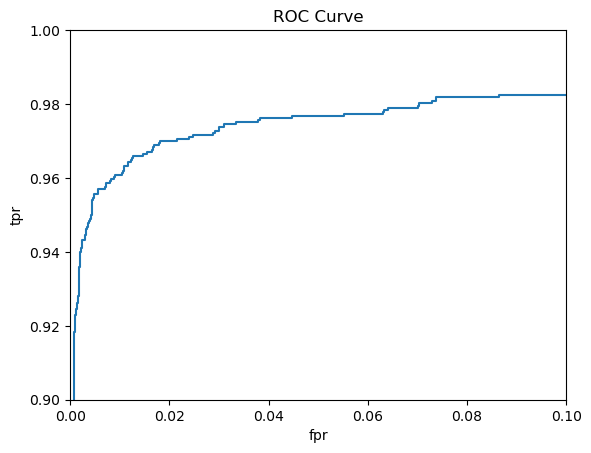

In [26]:
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC Curve');

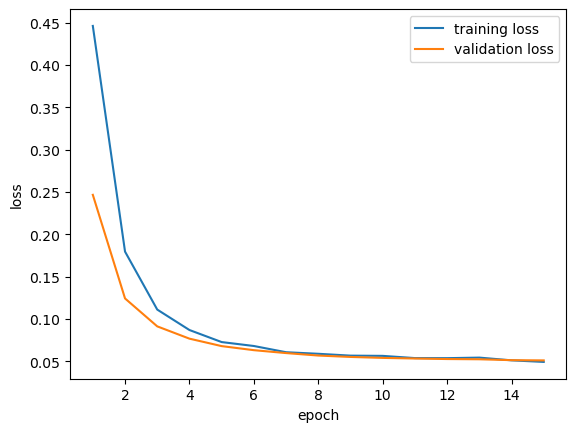

In [27]:
last_epoch = len(clf.history['loss'])
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['loss'], label='training loss')
plt.plot(epochs,clf.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')

plt.legend();

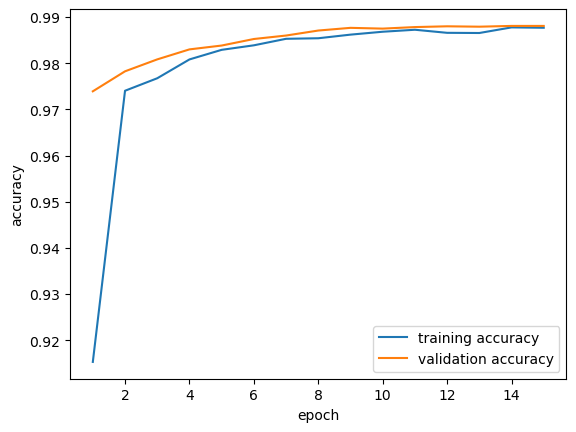

In [28]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['accuracy'], label='training accuracy')
plt.plot(epochs,clf.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')

plt.legend();

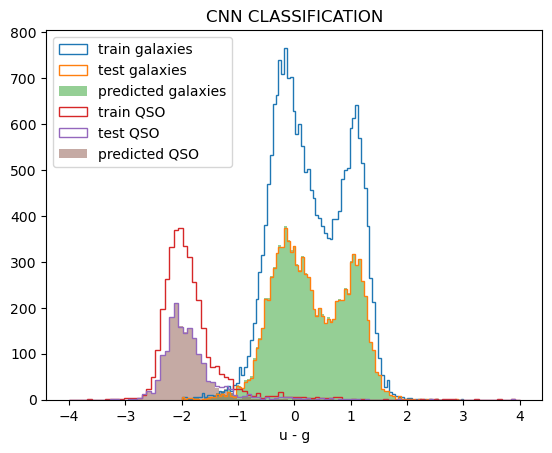

In [29]:
plt.hist(X_train[:,0][y_train==0], bins, histtype='step', label='train galaxies')
plt.hist(X_test[:,0][y_test==0], bins, histtype='step', label='test galaxies')
plt.hist(X_test[:,0][y_pred==0], bins, label='predicted galaxies', alpha = 0.5)

plt.hist(X_train[:,0][y_train==1], bins2, histtype='step', label='train QSO')
plt.hist(X_test[:,0][y_test==1], bins2, histtype='step', label='test QSO')
plt.hist(X_test[:,0][y_pred==1], bins2, label='predicted QSO', alpha = 0.5)

plt.title('CNN CLASSIFICATION')
plt.xlabel('u - g')
plt.legend();

# More complex CNN model

In [30]:
from tensorflow import keras


keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tf.random.set_seed(42)



X_valid, X_train = X_train_full[:12000], X_train_full[12000:]
y_valid, y_train = y_train_full[:12000], y_train_full[12000:]
X_test = X_test_full 
y_test = y_test_full

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)


(25500, 5) (25500,)
(12000, 5) (12000,)
(12500, 5) (12500,)


In [31]:
X_train = X_train[:,:,np.newaxis]
X_valid = X_valid[:,:,np.newaxis]
X_test = X_test[:,:,np.newaxis]

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(25500, 5, 1) (25500,)
(12000, 5, 1) (12000,)
(12500, 5, 1) (12500,)


In [32]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=(5,1)),
    keras.layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same'),
    keras.layers.Dropout(0.3),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(32, 3, activation='relu', padding='same'),
    keras.layers.Dropout(0.3),
    # keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
    # keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
    keras.layers.Dropout(0.3),
    keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5), 
    keras.layers.Dense(units=64, activation='relu'), 
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=2, activation='softmax'),
])

/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [33]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 32)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 16)          │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 16)          │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,242 (71.26 KB)

 Trainable params: 18,242 (71.26 KB)

 Non-trainable params: 0 (0.00 B)

None


In [34]:
# last_epoch = 30

# model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0005), metrics=["accuracy"])
# clf = model.fit(X_train, y_train, epochs=last_epoch, validation_data=(X_valid, y_valid))
last_epoch = 15 

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=0.00001)


model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0003), metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=last_epoch, validation_data=(X_valid, y_valid), callbacks=[early_stopping_cb, reduce_lr_cb])

Epoch 1/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9016 - loss: 0.3287 - val_accuracy: 0.9887 - val_loss: 0.0651 - learning_rate: 3.0000e-04
Epoch 2/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9855 - loss: 0.0692 - val_accuracy: 0.9893 - val_loss: 0.0565 - learning_rate: 3.0000e-04
Epoch 3/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9872 - loss: 0.0583 - val_accuracy: 0.9893 - val_loss: 0.0515 - learning_rate: 3.0000e-04
Epoch 4/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9874 - loss: 0.0511 - val_accuracy: 0.9891 - val_loss: 0.0529 - learning_rate: 3.0000e-04
Epoch 5/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9877 - loss: 0.0506 - val_accuracy: 0.9887 - val_loss: 0.0505 - learning_rate: 3.0000e-04
Epoch 6/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9888 - loss: 0.0506 - val_accuracy: 0.9895 - val_loss: 0.0424 - learning_rate: 3.0000e-04
Epoch 7/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - a

In [35]:
X_new = X_test[:20]
y_proba = model.predict(X_new).round(4)
y_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


array([[9.923e-01, 7.700e-03],
       [9.995e-01, 5.000e-04],
       [9.992e-01, 8.000e-04],
       [9.989e-01, 1.100e-03],
       [5.700e-03, 9.943e-01],
       [9.983e-01, 1.700e-03],
       [9.996e-01, 4.000e-04],
       [9.993e-01, 7.000e-04],
       [9.996e-01, 4.000e-04],
       [9.997e-01, 3.000e-04],
       [9.988e-01, 1.200e-03],
       [9.996e-01, 4.000e-04],
       [9.997e-01, 3.000e-04],
       [9.996e-01, 4.000e-04],
       [9.993e-01, 7.000e-04],
       [9.995e-01, 5.000e-04],
       [9.997e-01, 3.000e-04],
       [9.986e-01, 1.400e-03],
       [9.998e-01, 2.000e-04],
       [1.200e-03, 9.988e-01]], dtype=float32)

In [36]:
y_pred = np.argmax(model.predict(X_test), axis=-1)

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [37]:
completeness, contamination = completeness_contamination(y_pred, y_test)

print("completeness", completeness)
print("contamination", contamination)

C = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = C.ravel()

print(C)

print("\nfraction of correct classifications", (tp+tn)/(tp+fp+tn+fn))

completeness 0.9540816326530612
contamination 0.014637002341920375
[[10711    25]
 [   81  1683]]

fraction of correct classifications 0.99152


In [38]:
model

<Sequential name=sequential, built=True>

In [39]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_test))))[:,1]
y_prob.shape 

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


(12500,)

In [40]:
fpr, tpr, thresh = roc_curve(y_test, y_prob)

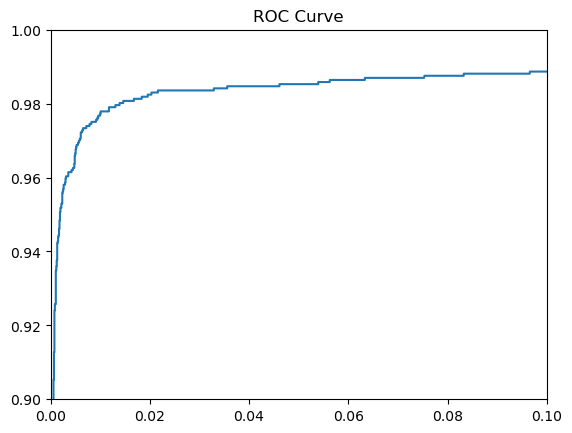

In [41]:
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.title('ROC Curve');

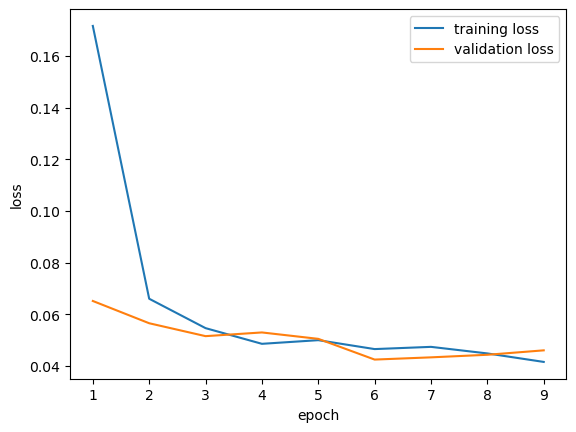

In [42]:
last_epoch = len(clf.history['loss'])
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['loss'], label='training loss')
plt.plot(epochs,clf.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')

plt.legend();

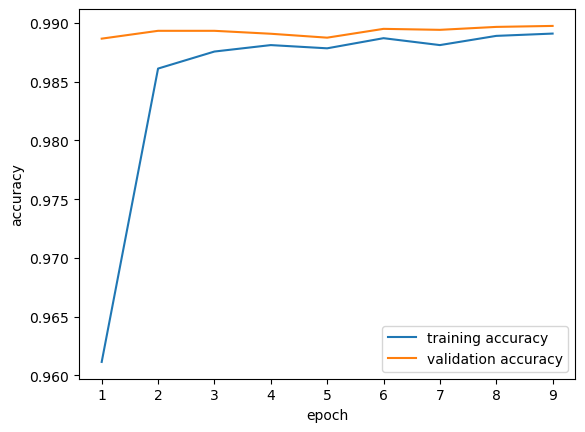

In [43]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['accuracy'], label='training accuracy')
plt.plot(epochs,clf.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')

plt.legend();

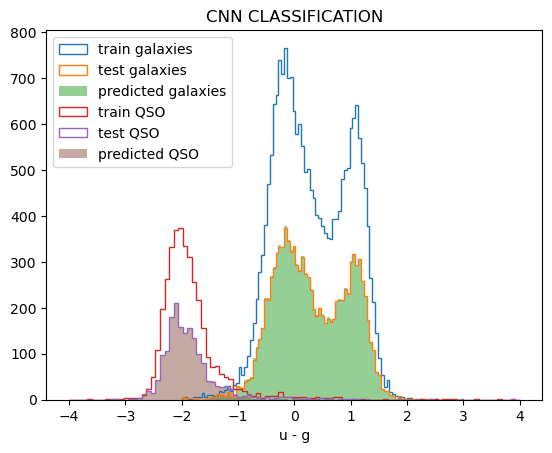

In [44]:
plt.hist(X_train[:,0][y_train==0], bins, histtype='step', label='train galaxies')
plt.hist(X_test[:,0][y_test==0], bins, histtype='step', label='test galaxies')
plt.hist(X_test[:,0][y_pred==0], bins, label='predicted galaxies', alpha = 0.5)

plt.hist(X_train[:,0][y_train==1], bins2, histtype='step', label='train QSO')
plt.hist(X_test[:,0][y_test==1], bins2, histtype='step', label='test QSO')
plt.hist(X_test[:,0][y_pred==1], bins2, label='predicted QSO', alpha = 0.5)


plt.title('CNN CLASSIFICATION')
plt.xlabel('u - g')
plt.legend();

# Cross validation on learning rate

(Best not to rerun these cells every time)
-

Learning Rate Finder
-
I'm looking for (not too wide) a range of lr from which to start my CV

In [45]:
import math
import numpy as np # Ensure numpy is imported

class LearningRateFinder(keras.callbacks.Callback):
    def __init__(self, start_lr, end_lr, num_iter, batch_size=None):
        super().__init__()
        self.start_lr = start_lr
        self.end_lr = end_lr
        self.num_iter = num_iter
        self.batch_size = batch_size
        self.lr_history = []
        self.loss_history = []
        self.best_loss = float('inf')

    def on_train_begin(self, logs=None):
        self.lrs = np.exp(np.linspace(math.log(self.start_lr), math.log(self.end_lr), self.num_iter)) # Generate learning rates logarithmically
        self.current_iter = 0
        self.model.optimizer.learning_rate = self.start_lr

    def on_train_batch_begin(self, batch, logs=None):
        if self.current_iter >= self.num_iter:
            self.model.stop_training = True
            return

        lr = self.lrs[self.current_iter]
        # Update learning rate for the current batch directly on the optimizer
        self.model.optimizer.learning_rate = lr

    def on_train_batch_end(self, batch, logs=None):
        loss = logs.get('loss')
        lr = self.model.optimizer.learning_rate.numpy()
        self.lr_history.append(lr)
        self.loss_history.append(loss)

        if loss < self.best_loss:
            self.best_loss = loss
        
        # Stop if loss becomes larger than 4x the best loss
        # if loss > 10 * self.best_loss:
        #     self.model.stop_training = True

        self.current_iter += 1


# Re-define and compile the model to get a fresh start for the LR finder
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# Using the same model architecture as the 'More complex CNN model' (cell 10f126bd-2bd7-4cf2-a0c2-bd54f2b8e139)
model_lr_finder = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=(5,1)),
    keras.layers.Conv1D(filters=32, kernel_size=7, activation='relu', padding='same'),
    keras.layers.Dropout(0.3),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(32, 3, activation='relu', padding='same'),
    keras.layers.Dropout(0.3),
    keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
    keras.layers.Dropout(0.3),
    keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=2, activation='softmax'),
])

model_lr_finder.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.Nadam(learning_rate=0.000001), # Start with a very low LR
    metrics=["accuracy"]
)

# Instantiate and run the Learning Rate Finder
lr_finder = LearningRateFinder(start_lr=1e-6, end_lr=1e-1, num_iter=len(X_train) // 64 * 5) # num_iter = batches_per_epoch * num_epochs_for_finder

print("Running Learning Rate Finder...")
history_lr = model_lr_finder.fit(X_train, y_train, epochs=5, batch_size=64, callbacks=[lr_finder])
print("Learning Rate Finder finished.")

Running Learning Rate Finder...
Epoch 1/5


/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6221 - loss: 0.6924
Epoch 2/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8533 - loss: 0.6654
Epoch 3/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9165 - loss: 0.1937
Epoch 4/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9856 - loss: 0.0678
Epoch 5/5
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9421 - loss: 0.2984
Learning Rate Finder finished.


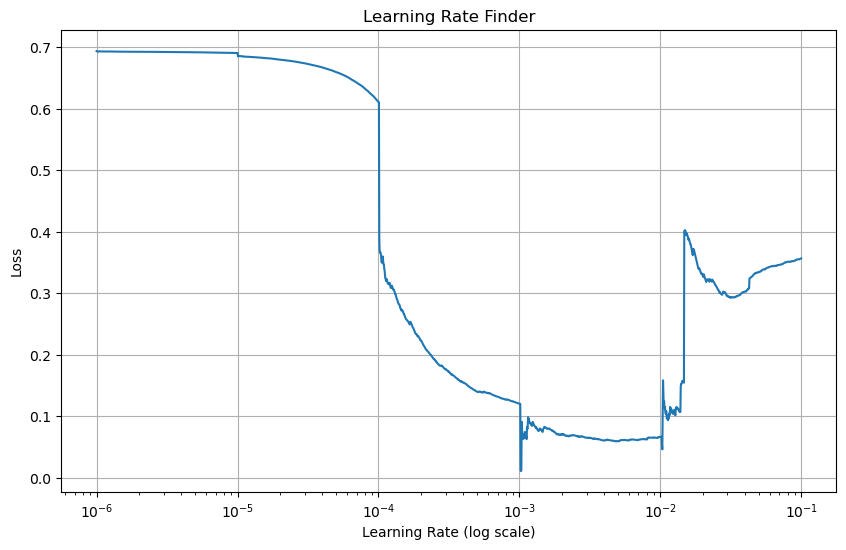

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(lr_finder.lr_history, lr_finder.loss_history)
plt.xscale('log')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Loss')
plt.title('Learning Rate Finder')
plt.grid();

Cross validation on LR
-

In [47]:
candidate_learning_rates = [0.0001, 0.0003, 0.0005, 0.0007, 0.001]
fixed_kernel_size = 5 # The kernel size was fixed to 7 in the original model
results_lr_only = {}


for lr in candidate_learning_rates:
    print(f"\n--- Training with Learning Rate: {lr} ---")
    keras.backend.clear_session()
    np.random.seed(42)
    tf.random.set_seed(42)

    model_cv_lr_only = keras.models.Sequential([
        keras.layers.InputLayer(input_shape=(5,1)),
        keras.layers.Conv1D(filters=32, kernel_size=fixed_kernel_size, activation='relu', padding='same'),
        keras.layers.Dropout(0.3),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Conv1D(32, 3, activation='relu', padding='same'),
        keras.layers.Dropout(0.3),
        keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
        keras.layers.Dropout(0.3),
        keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
        keras.layers.Flatten(),
        keras.layers.Dense(units=128, activation='relu'),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(units=64, activation='relu'),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(units=2, activation='softmax'),
    ])

    model_cv_lr_only.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=keras.optimizers.Nadam(learning_rate=lr),
        metrics=["accuracy"]
    )

    early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=0.00001)

    history = model_cv_lr_only.fit(
        X_train, y_train, epochs=20,
        validation_data=(X_valid, y_valid),
        callbacks=[early_stopping_cb, reduce_lr_cb],
        verbose=0
    )

    test_loss, test_accuracy = model_cv_lr_only.evaluate(X_test, y_test, verbose=0)
    print(f"  Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

    results_lr_only[lr] = {
        'history': history,
        'test_loss': test_loss,
        'test_accuracy': test_accuracy
    }

for lr, data in results_lr_only.items():
    print(f"LR: {lr}, Test Accuracy: {data['test_accuracy']:.4f}, Test Loss: {data['test_loss']:.4f}")


--- Training with Learning Rate: 0.0001 ---
  Test Loss: 0.0301, Test Accuracy: 0.9917

--- Training with Learning Rate: 0.0003 ---
  Test Loss: 0.0295, Test Accuracy: 0.9918

--- Training with Learning Rate: 0.0005 ---
  Test Loss: 0.0291, Test Accuracy: 0.9911

--- Training with Learning Rate: 0.0007 ---
  Test Loss: 0.0284, Test Accuracy: 0.9918

--- Training with Learning Rate: 0.001 ---
  Test Loss: 0.0275, Test Accuracy: 0.9921
LR: 0.0001, Test Accuracy: 0.9917, Test Loss: 0.0301
LR: 0.0003, Test Accuracy: 0.9918, Test Loss: 0.0295
LR: 0.0005, Test Accuracy: 0.9911, Test Loss: 0.0291
LR: 0.0007, Test Accuracy: 0.9918, Test Loss: 0.0284
LR: 0.001, Test Accuracy: 0.9921, Test Loss: 0.0275


In [48]:
candidate_learning_rates = [0.0001, 0.0003, 0.0005, 0.0007, 0.001]
candidate_kernel_sizes = [2, 3, 5] # Add candidate kernel sizes
results = {}

for lr in candidate_learning_rates:
    results[lr] = {} # Initialize nested dictionary for kernel sizes
    for ks in candidate_kernel_sizes:
        print(f"\n--- Training with Learning Rate: {lr}, Kernel Size: {ks} ---")
        keras.backend.clear_session()
        np.random.seed(42)
        tf.random.set_seed(42)

        model_cv = keras.models.Sequential([
            keras.layers.InputLayer(input_shape=(5,1)),
            # Use current kernel_size (ks) for the first Conv1D layer
            keras.layers.Conv1D(filters=32, kernel_size=ks, activation='relu', padding='same'),
            keras.layers.Dropout(0.3),
            keras.layers.MaxPooling1D(pool_size=2),
            keras.layers.Conv1D(32, 3, activation='relu', padding='same'),
            keras.layers.Dropout(0.3),
            keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
            keras.layers.MaxPooling1D(pool_size=2),
            keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
            keras.layers.Dropout(0.3),
            keras.layers.Conv1D(16, 3, activation='relu', padding='same'),
            keras.layers.Flatten(),
            keras.layers.Dense(units=128, activation='relu'),
            keras.layers.Dropout(0.5),
            keras.layers.Dense(units=64, activation='relu'),
            keras.layers.Dropout(0.5),
            keras.layers.Dense(units=2, activation='softmax'),
        ])

        model_cv.compile(
            loss="sparse_categorical_crossentropy",
            optimizer=keras.optimizers.Nadam(learning_rate=lr),
            metrics=["accuracy"]
        )

        # Use EarlyStopping and ReduceLROnPlateau as before
        early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
        reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=0.00001)

        history = model_cv.fit(
            X_train, y_train, epochs=20, # Increase epochs for full training
            validation_data=(X_valid, y_valid),
            callbacks=[early_stopping_cb, reduce_lr_cb],
            verbose=0 # Suppress verbose output for cleaner presentation
        )

        # Evaluate on test set
        test_loss, test_accuracy = model_cv.evaluate(X_test, y_test, verbose=0)
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

        results[lr][ks] = {
            'history': history,
            'test_loss': test_loss,
            'test_accuracy': test_accuracy
        }

print("\n--- Cross-validation results ---")
for lr, ks_results in results.items():
    for ks, data in ks_results.items():
        print(f"LR: {lr}, KS: {ks}, Test Accuracy: {data['test_accuracy']:.4f}, Test Loss: {data['test_loss']:.4f}")


--- Training with Learning Rate: 0.0001, Kernel Size: 2 ---
Test Loss: 0.0340, Test Accuracy: 0.9897

--- Training with Learning Rate: 0.0001, Kernel Size: 3 ---
Test Loss: 0.0345, Test Accuracy: 0.9906

--- Training with Learning Rate: 0.0001, Kernel Size: 5 ---
Test Loss: 0.0315, Test Accuracy: 0.9912

--- Training with Learning Rate: 0.0003, Kernel Size: 2 ---
Test Loss: 0.0310, Test Accuracy: 0.9914

--- Training with Learning Rate: 0.0003, Kernel Size: 3 ---
Test Loss: 0.0308, Test Accuracy: 0.9918

--- Training with Learning Rate: 0.0003, Kernel Size: 5 ---
Test Loss: 0.0291, Test Accuracy: 0.9915

--- Training with Learning Rate: 0.0005, Kernel Size: 2 ---
Test Loss: 0.0311, Test Accuracy: 0.9915

--- Training with Learning Rate: 0.0005, Kernel Size: 3 ---
Test Loss: 0.0318, Test Accuracy: 0.9911

--- Training with Learning Rate: 0.0005, Kernel Size: 5 ---
Test Loss: 0.0283, Test Accuracy: 0.9916

--- Training with Learning Rate: 0.0007, Kernel Size: 2 ---
Test Loss: 0.0328, Te